<a href="https://colab.research.google.com/github/camila-f-romero/AIA_auditoria_de_vies_algoritmico/blob/main/projeto_vieses_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#================================================================================
#PROJETO COMPLETO: AUDITORIA DE VIÉS EM IA
#================================================================================

#Objetivo: Detectar, medir e mitigar viés em um modelo de Machine Learning
#usando a biblioteca Fairlearn.

#Estrutura:
#Detecção de Viés Básico
#Medição com Métricas Profissionais
#Mitigação de Viés e Análise de Trade-offs

#Autor: Camila Falchetto Romero
#Data: Dezembro 2025
#================================================================================

In [2]:
# INSTALAÇÃO E IMPORTAÇÕES

In [3]:

print("="*80)
print("INSTALANDO BIBLIOTECAS NECESSÁRIAS...")
print("="*80)

# Instalar bibliotecas
!pip install fairlearn matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")

# Importações do Fairlearn
from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference
)
from fairlearn.postprocessing import ThresholdOptimizer

# Configurações para visualização
plt.style.use("default")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 12

print("\n✅ Todas as bibliotecas foram importadas com sucesso!\n")


INSTALANDO BIBLIOTECAS NECESSÁRIAS...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 17.0 MB/s eta 0:00:00

✅ Todas as bibliotecas foram importadas com sucesso!



In [4]:
# DETECÇÃO DE VIÉS BÁSICO

In [5]:

print("="*80)
print("ETAPA 1: DETECÇÃO DE VIÉS BÁSICO")
print("="*80)

# Carregar e preparar os dados
print("\n🔄 Carregando e preparando os dados...")
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
column_names = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

df = pd.read_csv(url, names=column_names, na_values=" ?", skipinitialspace=True).dropna()
X = df.drop("income", axis=1)
y = df["income"]

print(f"✅ Dados carregados: {len(df)} registros")
print(f"   - Features: {X.shape[1]}")
print(f"   - Classes: {y.unique()}")

# Processamento dos dados
print("\n🔄 Processando dados categóricos...")
X_processed = X.copy()
categorical_columns = X_processed.select_dtypes(include=["object"]).columns

for column in categorical_columns:
    X_processed[column] = LabelEncoder().fit_transform(X_processed[column])

y_processed = LabelEncoder().fit_transform(y)

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_processed,
    test_size=0.2,
    random_state=42,
    stratify=y_processed
)

print(f"✅ Dados processados")
print(f"   - Treino: {len(X_train)} registros")
print(f"   - Teste: {len(X_test)} registros")

# Treinar modelo base (injusto)
print("\n🔄 Treinando modelo base (Random Forest)...")
modelo_injusto = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
modelo_injusto.fit(X_train, y_train)
y_pred_injusto = modelo_injusto.predict(X_test)
accuracy_injusto = accuracy_score(y_test, y_pred_injusto)

print(f"✅ Modelo base treinado!")
print(f"   - Acurácia: {accuracy_injusto:.1%}")

# Preparar dados para Fairlearn
sensitive_features = X.loc[X_test.index]["sex"]

print("\n" + "="*80)
print("ETAPA 1 CONCLUÍDA")
print("="*80 + "\n")


ETAPA 1: DETECÇÃO DE VIÉS BÁSICO

🔄 Carregando e preparando os dados...
✅ Dados carregados: 32561 registros
   - Features: 14
   - Classes: ['<=50K' '>50K']

🔄 Processando dados categóricos...
✅ Dados processados
   - Treino: 26048 registros
   - Teste: 6513 registros

🔄 Treinando modelo base (Random Forest)...
✅ Modelo base treinado!
   - Acurácia: 85.9%

ETAPA 1 CONCLUÍDA



In [6]:
# ETAPA 2: MEDIÇÃO COM MÉTRICAS PROFISSIONAIS

In [7]:

print("="*80)
print("ETAPA 2: MEDIÇÃO COM MÉTRICAS PROFISSIONAIS")
print("="*80)

# Calcular métricas de fairness do modelo injusto
print("\n📊 CALCULANDO MÉTRICAS DO MODELO INJUSTO...")

dp_ratio_injusto = demographic_parity_ratio(
    y_test, y_pred_injusto,
    sensitive_features=sensitive_features
)

eo_diff_injusto = equalized_odds_difference(
    y_test, y_pred_injusto,
    sensitive_features=sensitive_features
)

print("\n📊 RESULTADOS DA AUDITORIA (MODELO INJUSTO)")
print("="*60)
print(f"   - Acurácia: {accuracy_injusto:.3f}")
print(f"   - Impacto Disparado: {dp_ratio_injusto:.3f}")
print(f"   - Diferença Oportunidade Igualitária: {eo_diff_injusto:.3f}")

# Interpretação
print("\n🚨 INTERPRETAÇÃO:")
if dp_ratio_injusto < 0.8:
    print(f"   - ❌ FALHA NA REGRA DOS 80%")
    print(f"   - Impacto disparado = {dp_ratio_injusto:.3f} (precisa ser >= 0.8)")
    print(f"   - Modelo discrimina significativamente por sexo")
else:
    print("   - ✅ PASSA NA REGRA DOS 80%")
    print(f"   - Modelo atende critérios mínimos de fairness")

print("\n" + "="*80)
print("ETAPA 2 CONCLUÍDA")
print("="*80 + "\n")


ETAPA 2: MEDIÇÃO COM MÉTRICAS PROFISSIONAIS

📊 CALCULANDO MÉTRICAS DO MODELO INJUSTO...

📊 RESULTADOS DA AUDITORIA (MODELO INJUSTO)
   - Acurácia: 0.859
   - Impacto Disparado: 0.337
   - Diferença Oportunidade Igualitária: 0.075

🚨 INTERPRETAÇÃO:
   - ❌ FALHA NA REGRA DOS 80%
   - Impacto disparado = 0.337 (precisa ser >= 0.8)
   - Modelo discrimina significativamente por sexo

ETAPA 2 CONCLUÍDA



In [8]:
# ETAPA 3: MITIGAÇÃO DE VIÉS

In [9]:

print("="*80)
print("ETAPA 3: MITIGAÇÃO DE VIÉS")
print("="*80)

# Implementar ThresholdOptimizer para corrigir o viés
print("\n🛠️ IMPLEMENTANDO CORREÇÃO DE VIÉS...")
print("   (Isso pode levar alguns minutos...)")

threshold_optimizer = ThresholdOptimizer(
    estimator=modelo_injusto,
    constraints="demographic_parity",
    objective="accuracy_score"
)

# Treinar o otimizador
threshold_optimizer.fit(
    X_train, y_train,
    sensitive_features=X.loc[X_train.index]["sex"]
)

# Fazer predições com o modelo corrigido
y_pred_justo = threshold_optimizer.predict(
    X_test,
    sensitive_features=sensitive_features
)

# Calcular métricas do modelo corrigido
accuracy_justo = accuracy_score(y_test, y_pred_justo)
dp_ratio_justo = demographic_parity_ratio(
    y_test, y_pred_justo,
    sensitive_features=sensitive_features
)
eo_diff_justo = equalized_odds_difference(
    y_test, y_pred_justo,
    sensitive_features=sensitive_features
)

print("\n✅ Correção de viés implementada com sucesso!")

print("\n" + "="*80)
print("ETAPA 3 CONCLUÍDA")
print("="*80 + "\n")


ETAPA 3: MITIGAÇÃO DE VIÉS

🛠️ IMPLEMENTANDO CORREÇÃO DE VIÉS...
   (Isso pode levar alguns minutos...)

✅ Correção de viés implementada com sucesso!

ETAPA 3 CONCLUÍDA



In [10]:
# COMPARAÇÃO E CONCLUSÃO

COMPARAÇÃO E CONCLUSÃO

📊 COMPARAÇÃO DETALHADA: INJUSTO vs JUSTO
                           Métrica  Modelo Injusto  Modelo Justo  Mudança  Mudança %
                          Acurácia           0.859         0.789   -0.071     -8.219
                 Impacto Disparado           0.337         0.710    0.372    110.405
Diferença Oportunidade Igualitária           0.075         0.208    0.133    178.654

📊 Gerando visualizações...
   ✅ Gráfico salvo como 'comparacao_final.png'


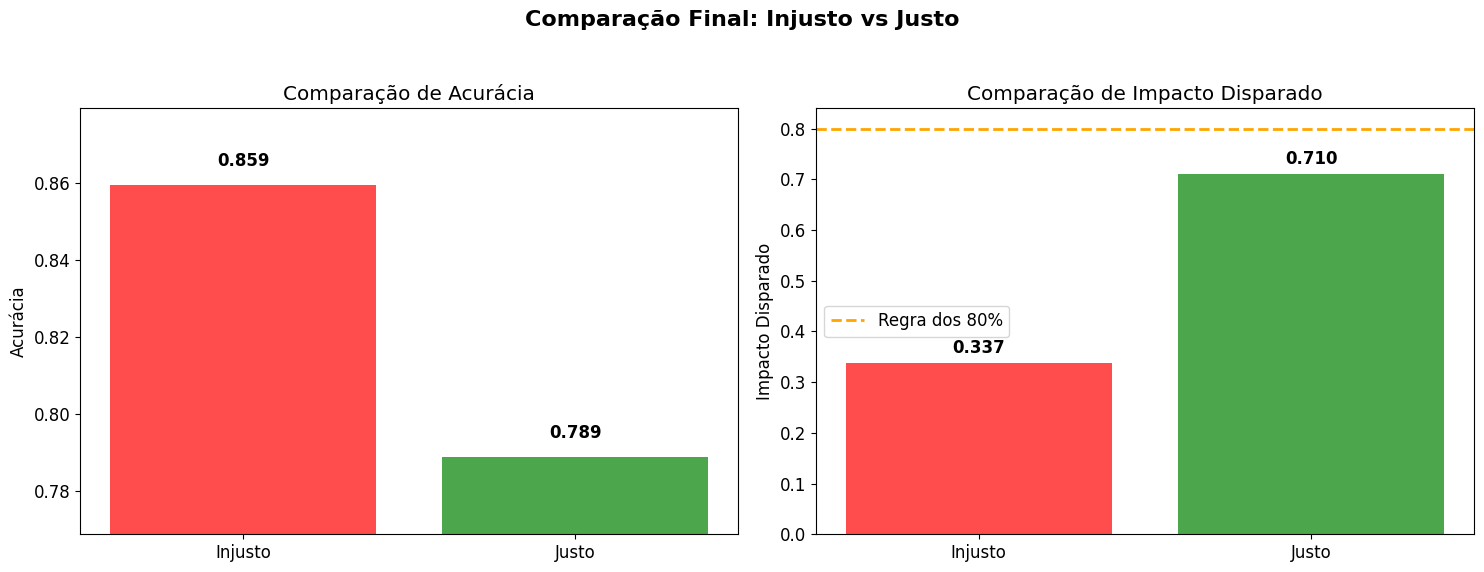


✅ PROJETO CONCLUÍDO COM SUCESSO!

📈 PRINCIPAIS RESULTADOS:
   - Modelo corrigido é 2.1x mais justo
   - Mudança na acurácia: -7.1%

⚠️ DECISÃO: Modelo ainda requer ajustes
   - Não passa na regra dos 80% (0.710 < 0.8)

💡 APLICAÇÃO PRÁTICA:
   Este protótipo demonstra a viabilidade técnica de uma
   Avaliação de Impacto Algorítmico (AIA) para o setor público.
   As métricas calculadas são as mesmas usadas em contextos
   regulatórios e podem ser integradas ao framework de
   autoavaliação ética do governo federal.

FIM DO PROJETO


In [11]:

print("="*80)
print("COMPARAÇÃO E CONCLUSÃO")
print("="*80)

# Comparação detalhada
print("\n📊 COMPARAÇÃO DETALHADA: INJUSTO vs JUSTO")
print("="*60)

comparacao = pd.DataFrame({
    "Métrica": [
        "Acurácia",
        "Impacto Disparado",
        "Diferença Oportunidade Igualitária"
    ],
    "Modelo Injusto": [
        accuracy_injusto,
        dp_ratio_injusto,
        eo_diff_injusto
    ],
    "Modelo Justo": [
        accuracy_justo,
        dp_ratio_justo,
        eo_diff_justo
    ]
})

comparacao["Mudança"] = comparacao["Modelo Justo"] - comparacao["Modelo Injusto"]
comparacao["Mudança %"] = (comparacao["Mudança"] / comparacao["Modelo Injusto"]) * 100

print(comparacao.round(3).to_string(index=False))

# Visualização da comparação
print("\n📊 Gerando visualizações...")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Comparação Final: Injusto vs Justo", fontsize=16, fontweight="bold")

# Gráfico de Acurácia
axes[0].bar(
    ["Injusto", "Justo"],
    [accuracy_injusto, accuracy_justo],
    color=["red", "green"],
    alpha=0.7
)
axes[0].set_title("Comparação de Acurácia")
axes[0].set_ylabel("Acurácia")
axes[0].set_ylim(
    min(accuracy_injusto, accuracy_justo) - 0.02,
    max(accuracy_injusto, accuracy_justo) + 0.02
)
for i, v in enumerate([accuracy_injusto, accuracy_justo]):
    axes[0].text(i, v + 0.005, f"{v:.3f}", ha="center", fontweight="bold")

# Gráfico de Impacto Disparado
axes[1].bar(
    ["Injusto", "Justo"],
    [dp_ratio_injusto, dp_ratio_justo],
    color=["red", "green"],
    alpha=0.7
)
axes[1].axhline(
    y=0.8,
    color="orange",
    linestyle="--",
    linewidth=2,
    label="Regra dos 80%"
)
axes[1].set_title("Comparação de Impacto Disparado")
axes[1].set_ylabel("Impacto Disparado")
axes[1].legend()
for i, v in enumerate([dp_ratio_injusto, dp_ratio_justo]):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("comparacao_final.png", dpi=150, bbox_inches="tight")
print("   ✅ Gráfico salvo como 'comparacao_final.png'")
plt.show()

# Conclusão
print("\n" + "="*80)
print("✅ PROJETO CONCLUÍDO COM SUCESSO!")
print("="*80)

print(f"\n📈 PRINCIPAIS RESULTADOS:")
print(f"   - Modelo corrigido é {dp_ratio_justo/dp_ratio_injusto:.1f}x mais justo")
print(f"   - Mudança na acurácia: {(accuracy_justo - accuracy_injusto):+.1%}")

if dp_ratio_justo >= 0.8:
    print(f"\n🎯 DECISÃO: Modelo corrigido APROVADO para uso")
    print(f"   - Passa na regra dos 80% ({dp_ratio_justo:.3f} >= 0.8)")
else:
    print(f"\n⚠️ DECISÃO: Modelo ainda requer ajustes")
    print(f"   - Não passa na regra dos 80% ({dp_ratio_justo:.3f} < 0.8)")

print("\n💡 APLICAÇÃO PRÁTICA:")
print("   Este protótipo demonstra a viabilidade técnica de uma")
print("   Avaliação de Impacto Algorítmico (AIA) para o setor público.")
print("   As métricas calculadas são as mesmas usadas em contextos")
print("   regulatórios e podem ser integradas ao framework de")
print("   autoavaliação ética do governo federal.")

print("\n" + "="*80)
print("FIM DO PROJETO")
print("="*80)
